In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Tutto funziona!")

Tutto funziona!


In [3]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info():

SyntaxError: invalid syntax (2716125607.py, line 1)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df.shape

(9994, 21)

In [9]:
df.describe(include="all").loc[["count", "unique", "top", "freq"],
      ["Segment", "Category", "Sub-Category", "Region", "Ship Mode"]]

,Segment,Category,Sub-Category,Region,Ship Mode
count,9994,9994,9994,9994,9994
unique,3,3,17,4,4
top,Consumer,Office Supplies,Binders,West,Standard Class
freq,5191,6026,1523,3203,5968


In [11]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

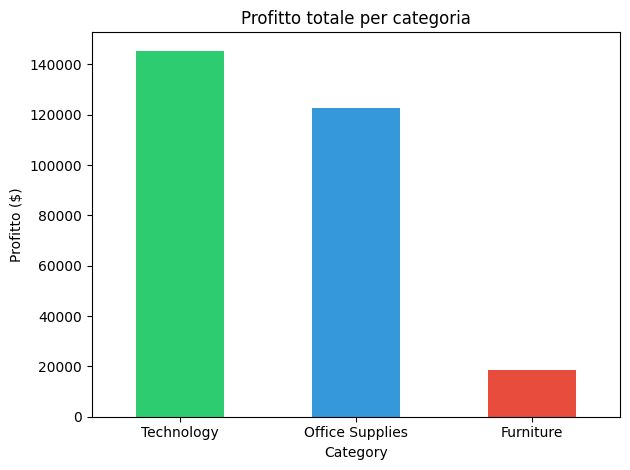

In [13]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False).plot(kind="bar",
color=["#2ecc71", "#3498db", "#e74c3c"], title="Profitto totale per categoria")
plt.ylabel("Profitto ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

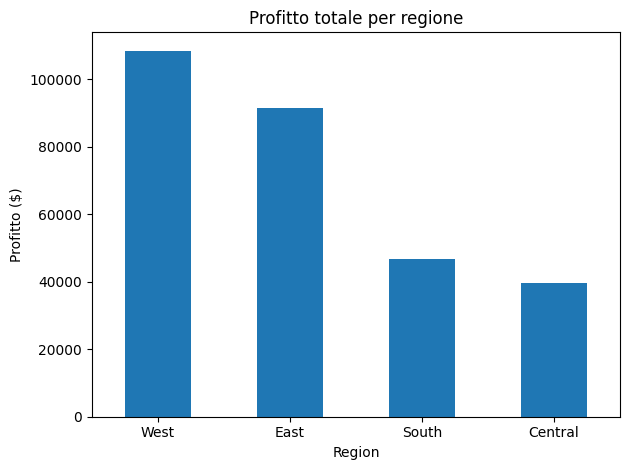

In [15]:
profitto_regione = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
profitto_regione.plot(kind="bar", title="Profitto totale per regione")
plt.ylabel("Profitto ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
correlazione = df[["Discount", "Profit"]].corr()
print(correlazione)

          Discount    Profit
Discount  1.000000 -0.219487
Profit   -0.219487  1.000000


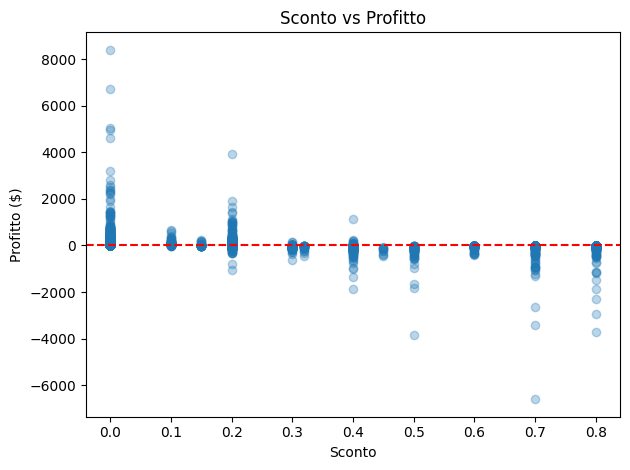

In [18]:
plt.scatter(df["Discount"], df["Profit"], alpha=0.3)
plt.xlabel("Sconto")
plt.ylabel("Profitto ($)")
plt.title("Sconto vs Profitto")
plt.axhline(y=0, color="red", linestyle="--")
plt.tight_layout()
plt.show()

In [19]:
df[df["Discount"] >= 0.4]["Profit"].sum()

np.float64(-122615.6409)

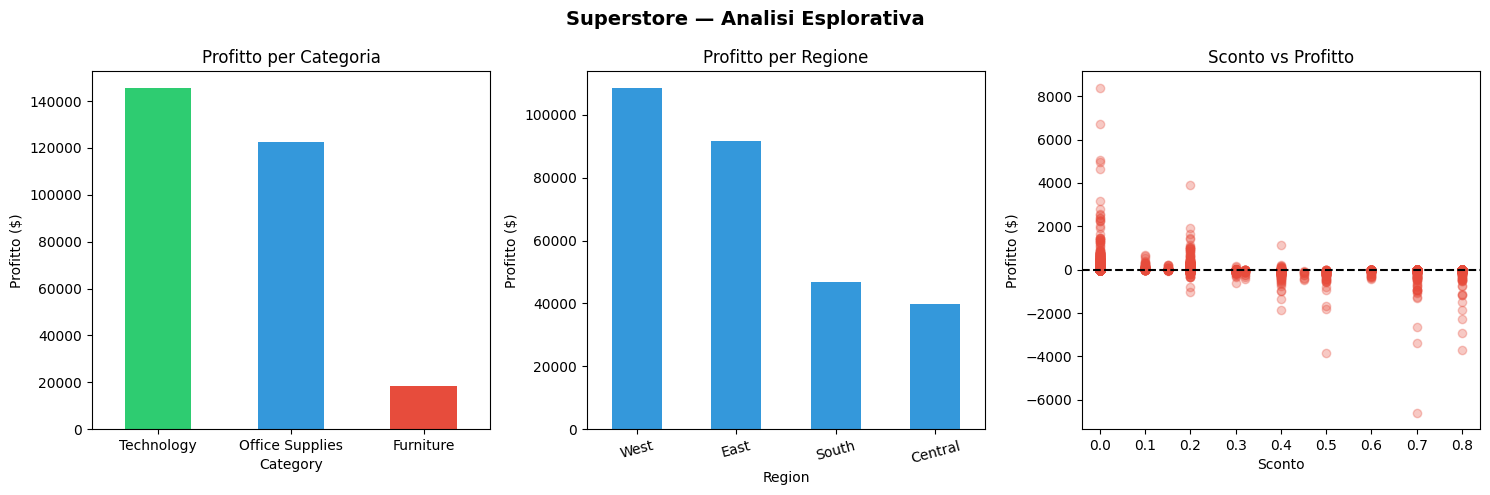

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.groupby("Category")["Profit"].sum().sort_values(ascending=False).plot(
kind="bar", ax=axes[0], title="Profitto per Categoria",
color=["#2ecc71","#3498db","#e74c3c"])
axes[0].set_ylabel("Profitto ($)")
axes[0].tick_params(axis="x", rotation=0)

df.groupby("Region")["Profit"].sum().sort_values(ascending=False).plot(
kind="bar", ax=axes[1], title="Profitto per Regione", color="#3498db")
axes[1].set_ylabel("Profitto ($)")
axes[1].tick_params(axis="x", rotation=15)

axes[2].scatter(df["Discount"], df["Profit"], alpha=0.3, color="#e74c3c")
axes[2].axhline(y=0, color="black", linestyle="--")
axes[2].set_title("Sconto vs Profitto")
axes[2].set_xlabel("Sconto")
axes[2].set_ylabel("Profitto ($)")

plt.suptitle("Superstore — Analisi Esplorativa", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()